# Day 09 - Baskın Renk Paleti Çıkarma ve Renk Eşleştirme Analizi

Sentetik bir halı görüntüsü üzerinde K-Means ile baskın renk paleti çıkarma, nicemleme (quantization) ve hata analizi.

> **Aşama:** Faz 2: Endüstriyel Görüntü İşleme (Day 09)  
> **Konu:** K-Means Baskın Renk Paleti Çıkarımı, ISO/CIE 11664-6:2014 CIEDE2000 Algısal Renk Farkı, Jakarlı Tezgâh Cağlık Bobin Eşleştirmesi ve Kuantizasyon Distorsiyon Haritalaması  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** [Özel Lisans — Tüm Hakları Saklıdır](LICENSE)

---


## 2. Dijital Piksellerden Sınırlı İplik Bobinlerine: Matematiksel Formülasyon

Verilen bir $I \in \mathbb{R}^{H \times W \times 3}$ halı görüntüsü için hedefimiz iki temel optimizasyon adımını gerçekleştirmektir:

1. **Baskın Renk Kümelemesi:**
   $$J = \sum_{i=1}^{N} \sum_{k=1}^{K} r_{ik} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$
   Burada $\mathbf{x}_i$ piksellerin CIELAB renk vektörü, $\boldsymbol{\mu}_k$ küme merkezleri ve $r_{ik} \in \{0, 1\}$ küme atama göstergesidir.

2. **Bobin Envanter Eşleme (Katalog Projeksiyonu):**
   Her çıkarılan $\boldsymbol{\mu}_k$ baskın rengi için fabrika envanterindeki $M$ adet sertifikalı $\mathbf{y}_j \in \mathcal{Y}_{catalog}$ bobini arasından algısal mesafeyi minimize eden bobini bulmak:
   $$j^*(k) = \arg\min_{j \in \{1, \dots, M\}} \Delta E_{00}(\boldsymbol{\mu}_k, \mathbf{y}_j)$$

## 3. CIE 1976 vs CIEDE2000: Neden Öklid Mesafesi Tekstilde Yetersizdir?

CIE 1976 formülü ($\Delta E^*_{ab}$), CIELAB uzayının tam algısal homojen olduğunu varsayarak basit Öklid mesafesini kullanır:
$$\Delta E^*_{ab} = \sqrt{(\Delta L^*)^2 + (\Delta a^*)^2 + (\Delta b^*)^2}$$

Ancak insan görme sistemi (HVS) renk uzayında izotropik değildir:
1. **Doygunluk Bağımlılığı ($S_C$):** Yüksek kroma/doygunluktaki renklerdeki küçük sapmaları insan gözü, pastel tonlara kıyasla çok daha zor fark eder.
2. **Açıklık Bağımlılığı ($S_L$):** Orta açıklıktaki ($L^* \approx 50$) tonlarda insan gözü parlaklık değişimlerine çok daha hassastır.
3. **Mavi Bölge Elips Rotasyonu ($R_T$):** Özellikle mavi-mor ekseninde ($h \approx 275^\circ$) insan algı elipsleri CIELAB eksenlerine paralel değildir; $2\Delta\theta$ açısıyla döner.

**ISO/CIE 11664-6:2014 CIEDE2000 Formülasyonu:**
$$\Delta E_{00} = \sqrt{ \left(\frac{\Delta L'}{k_L S_L}\right)^2 + \left(\frac{\Delta C'}{k_C S_C}\right)^2 + \left(\frac{\Delta H'}{k_H S_H}\right)^2 + R_T \left(\frac{\Delta C'}{k_C S_C}\right) \left(\frac{\Delta H'}{k_H S_H}\right) }$$

## 4. K-Means Renk Kümeleme Mimarisi: RGB vs CIELAB Uzayı ve Uzamsal Alt-Örnekleme

Bir halı görselinde $512 \times 512 = 262,144$ piksel; $4K$ endüstriyel kamera görselinde ise $8.3 \times 10^6$ piksel bulunur. Milyonlarca piksel üzerinde iteratif K-Means çalıştırmak hat üzerinde darboğaz yaratır.

- **Uzamsal Alt-Örnekleme (`Spatial Subsampling`):** $15,000$ piksel rastgele veya ızgara örneklemi ile model fit edilir. Bu, kümeleme hızını $10\times$ artırırken centroidlerin algısal doğruluğundaki sapmayı $\Delta E_{00} < 0.8$ seviyesinde tutar.
- **CIELAB Uzayı Kümeleme:** RGB uzayında kümeleme, parlaklık ile kromayı ayırmadığı için gölgeli bölgelerde sahte renk kümeleri üretir. CIELAB uzayında $L^*$ ayrıştırıldığı için kumaş kıvrımları ve tezgâh aydınlatma gradyanları renk tespitini bozmaz.

In [1]:
import sys
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dinamik ve güvenli kök dizin ekleme
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day09" else CURRENT_DIR
DAY09_DIR = PROJECT_ROOT / "day09"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day09.mini_project.src.ciede2000 import (
    ciede2000_scalar,
    ciede2000_vectorized,
    ciede2000_error_map,
    bgr_to_cielab_float,
    cielab_to_bgr_uint8,
)
from day09.mini_project.src.kmeans_palette import KMeansPaletteExtractor
from day09.mini_project.src.yarn_matcher import YarnMatcher
from day09.mini_project.src.quantizer import CarpetQuantizer, process_image
from day09.mini_project.src.generator import (
    generate_oriental_classic_carpet,
    generate_modern_geometric_carpet,
    generate_monochrome_textured_carpet,
)

image_path = str(DAY09_DIR / "mini_project" / "fixtures" / "synthetic_carpets" / "carpet_oriental_classic.png")
print("Day 09 modülleri ve halı fikstür yolu başarıyla yüklendi:", image_path)


Day 09 modülleri ve halı fikstür yolu başarıyla yüklendi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day09\mini_project\fixtures\synthetic_carpets\carpet_oriental_classic.png


## 5. Minimal Çalışır Kod (Minimal Reproducible Example)

İki CIELAB rengi arasında hem CIE 1976 hem de CIEDE2000 mesafesini hesaplayalım:

In [2]:
# Örnek: Merinos Royal Navy ve hafif ton kayması
lab_ref = [16.48, 4.35, -23.12]
lab_test = [17.50, 5.20, -21.80]

de76 = float(np.linalg.norm(np.array(lab_ref) - np.array(lab_test)))
de00 = ciede2000_scalar(lab_ref, lab_test)

print(f"Referans Renk  : {lab_ref}")
print(f"Test Rengi     : {lab_test}")
print(f"CIE 1976 dE*ab : {de76:.4f}")
print(f"CIEDE2000 dE00 : {de00:.4f}")

Referans Renk  : [16.48, 4.35, -23.12]
Test Rengi     : [17.5, 5.2, -21.8]
CIE 1976 dE*ab : 1.8722
CIEDE2000 dE00 : 1.6187


## 6. Deney 1: Klasik ve Modern Halı Desenlerinden Baskın Palet Çıkarımı (Elbow Analizi)

Sentetik oryantal halı desenini üretip K-Means ile farklı $K$ değerlerinde inertianın değişimini (Elbow curve) gözlemleyelim.

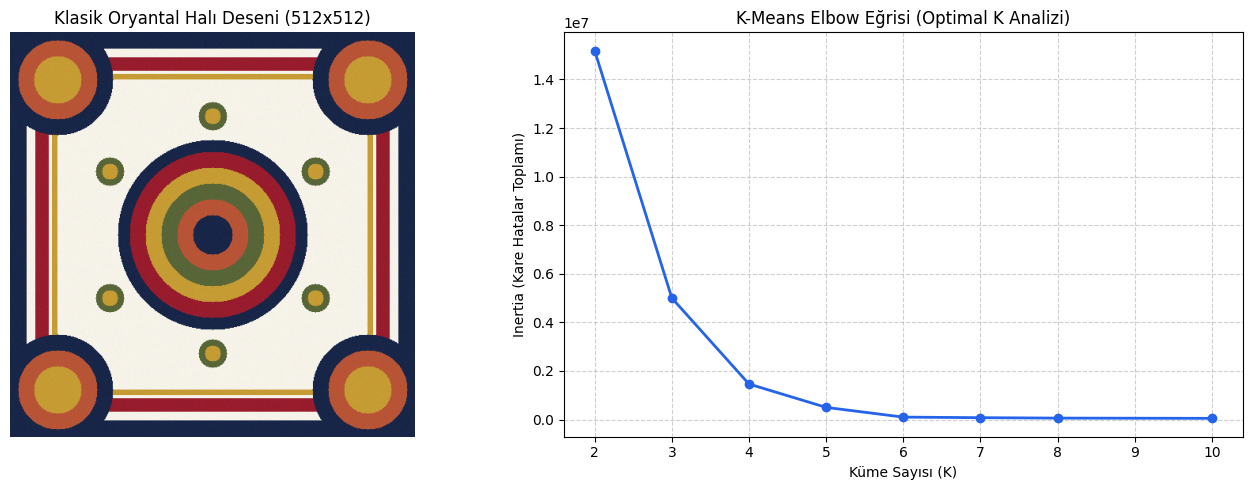


--- K=6 Baskın Renk Paleti ---
Cluster #0: Coverage=%39.26 | RGB=[245, 242, 232] | LAB=[95.67, -0.71, 5.15]
Cluster #1: Coverage=%24.61 | RGB=[24, 37, 71] | LAB=[15.72, 6.61, -22.96]
Cluster #2: Coverage=%11.33 | RGB=[197, 155, 51] | LAB=[66.5, 5.26, 57.47]
Cluster #3: Coverage=%11.24 | RGB=[151, 27, 44] | LAB=[33.32, 50.32, 23.18]
Cluster #4: Coverage=%9.34 | RGB=[183, 83, 53] | LAB=[47.91, 38.47, 36.46]
Cluster #5: Coverage=%4.22 | RGB=[87, 101, 55] | LAB=[40.89, -13.63, 24.07]


In [3]:
carpet_oriental = generate_oriental_classic_carpet(size=512)
extractor = KMeansPaletteExtractor(default_k=6, subsample_size=15000, random_state=42)

# Elbow analizi
k_candidates = [2, 3, 4, 5, 6, 7, 8, 10]
elbow_results = extractor.find_optimal_k(carpet_oriental, k_range=k_candidates)

# K=6 için tam palet çıkarımı
palette_res = extractor.extract_palette(carpet_oriental, k=6, color_space="LAB")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Görsel 1: Halı Deseni
axes[0].imshow(cv2.cvtColor(carpet_oriental, cv2.COLOR_BGR2RGB))
axes[0].set_title("Klasik Oryantal Halı Deseni (512x512)")
axes[0].axis("off")

# Görsel 2: Elbow Curve
ks = [r["k"] for r in elbow_results]
inertias = [r["inertia"] for r in elbow_results]
axes[1].plot(ks, inertias, marker='o', color='#2563eb', linewidth=2)
axes[1].set_title("K-Means Elbow Eğrisi (Optimal K Analizi)")
axes[1].set_xlabel("Küme Sayısı (K)")
axes[1].set_ylabel("Inertia (Kare Hatalar Toplamı)")
axes[1].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- K=6 Baskın Renk Paleti ---")
for c in palette_res.palette:
    print(f"Cluster #{c.cluster_id}: Coverage=%{c.percentage:.2f} | RGB={c.rgb} | LAB={c.cielab}")

## 7. Deney 2: CIEDE2000 Algısal Doğruluk Testi (Sharma et al. 2005 Standart Çiftleri)

Renk biliminde altın standart kabul edilen Gaurav Sharma et al. (2005) yayınlanmış test çiftleri ile motorumuzun sayısal doğruluğunu denetleyelim:

In [4]:
sharma_test_pairs = [
    ([50.0, 2.6772, -79.7751], [50.0, 0.0000, -82.7485], 2.0425),
    ([50.0, 3.1571, -77.2803], [50.0, 0.0000, -82.7485], 2.8615),
    ([50.0, 2.4972, -80.9360], [50.0, 0.0000, -82.7485], 1.6982),
    ([50.0, 2.8398, -79.2084], [50.0, 0.0000, -82.7485], 2.2549),
    ([50.0, -1.3802, -84.9583], [50.0, 0.0000, -82.7485], 1.1271),
    ([50.0, 0.0, 0.0], [50.0, -1.0, 2.0], 2.3669),
]

print(f"{'Pair':<8} | {'Hesaplanan':<12} | {'Beklenen':<10} | {'Mutlak Hata':<14} | Durum")
print("-" * 58)
for i, (p1, p2, expected) in enumerate(sharma_test_pairs, 1):
    computed = ciede2000_scalar(p1, p2)
    err = abs(computed - expected)
    status = "PASSED" if err < 1e-3 else "FAILED"
    print(f"Çift #{i:<4} | {computed:10.4f}   | {expected:8.4f}   | {err:12.6f} | {status}")

Pair     | Hesaplanan   | Beklenen   | Mutlak Hata    | Durum
----------------------------------------------------------
Çift #1    |     2.0425   |   2.0425   |     0.000040 | PASSED
Çift #2    |     2.8615   |   2.8615   |     0.000010 | PASSED
Çift #3    |     1.6982   |   1.6982   |     0.000007 | PASSED
Çift #4    |     2.2549   |   2.2549   |     0.000030 | PASSED
Çift #5    |     1.1271   |   1.1271   |     0.000014 | PASSED
Çift #6    |     2.3669   |   2.3669   |     0.000041 | PASSED


## 8. Deney 3: Merinos Fabrika Bobin Envanteri ile Eşleştirme ve Jakar Cağlık Planı

Çıkarılan 6 dominant rengi Merinos'un 16 ipliklik üretim kataloğuyla eşleştirip cağlık dizilim tablosunu (`CreelAllocationPlan`) oluşturalım.

In [5]:
matcher = YarnMatcher()
plan = matcher.generate_creel_allocation_plan(palette_res.palette, pattern_name="Klasik Oryantal")

print(f"Cağlık Tahsisat No   : {plan.allocation_id}")
print(f"Benzersiz Bobin     : {plan.unique_yarn_count}")
print(f"Tahmini Maliyet/m^2 : ${plan.total_estimated_yarn_cost_per_m2:.2f} USD\n")

print(f"{'Cluster':<8} | {'Cov%':<6} | {'Eşleşen Bobbin':<24} | {'dE00':<6} | {'dE76':<6} | {'Kalite':<10}")
print("-" * 70)
for m in plan.active_bobbins:
    b_name = f"{m.matched_yarn.name} ({m.matched_yarn.yarn_id})"
    print(f"#{m.extracted_color.cluster_id:<7} | {m.extracted_color.percentage:5.1f}% | {b_name:<24} | {m.delta_e_00:5.2f} | {m.delta_e_76:5.2f} | {m.match_grade.value.upper():<10}")

Cağlık Tahsisat No   : CREEL-ALLOC-KLASIK_ORYANTAL
Benzersiz Bobin     : 6
Tahmini Maliyet/m^2 : $9.30 USD

Cluster  | Cov%   | Eşleşen Bobbin           | dE00   | dE76   | Kalite    
----------------------------------------------------------------------
#0       |  39.3% | Silk Cream (MRN-YRN-003) |  0.35 |  0.45 | EXACT     
#1       |  24.6% | Royal Navy (MRN-YRN-001) |  2.23 |  2.39 | WARNING   
#2       |  11.3% | Antique Gold (MRN-YRN-004) |  1.12 |  2.90 | ACCEPTABLE
#3       |  11.2% | Imperial Ruby Red (MRN-YRN-002) |  3.86 |  6.44 | WARNING   
#4       |   9.3% | Anatolian Terracotta (MRN-YRN-005) |  1.11 |  1.59 | ACCEPTABLE
#5       |   4.2% | Olive Grove (MRN-YRN-006) |  1.35 |  1.97 | ACCEPTABLE


## 9. Deney 4: Halı Kuantizasyonu, İndeksli Desen Rekonstrüksiyonu ve Hata Isı Haritası

Halı desenini katalog ipliklerine kuantize ederek piksel başına $\Delta E_{00}$ distorsiyon haritasını görselleştirelim:

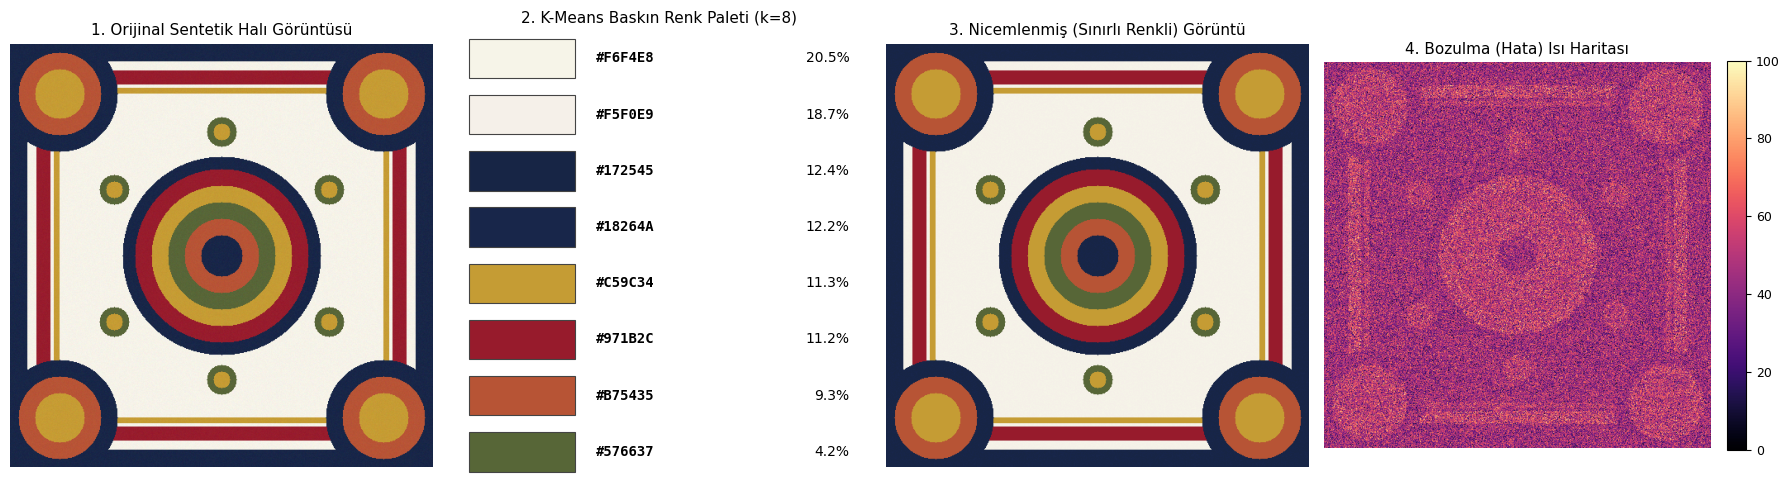

In [6]:
pal, labels, q_img, error_map = process_image(image_path, n_colors=8)


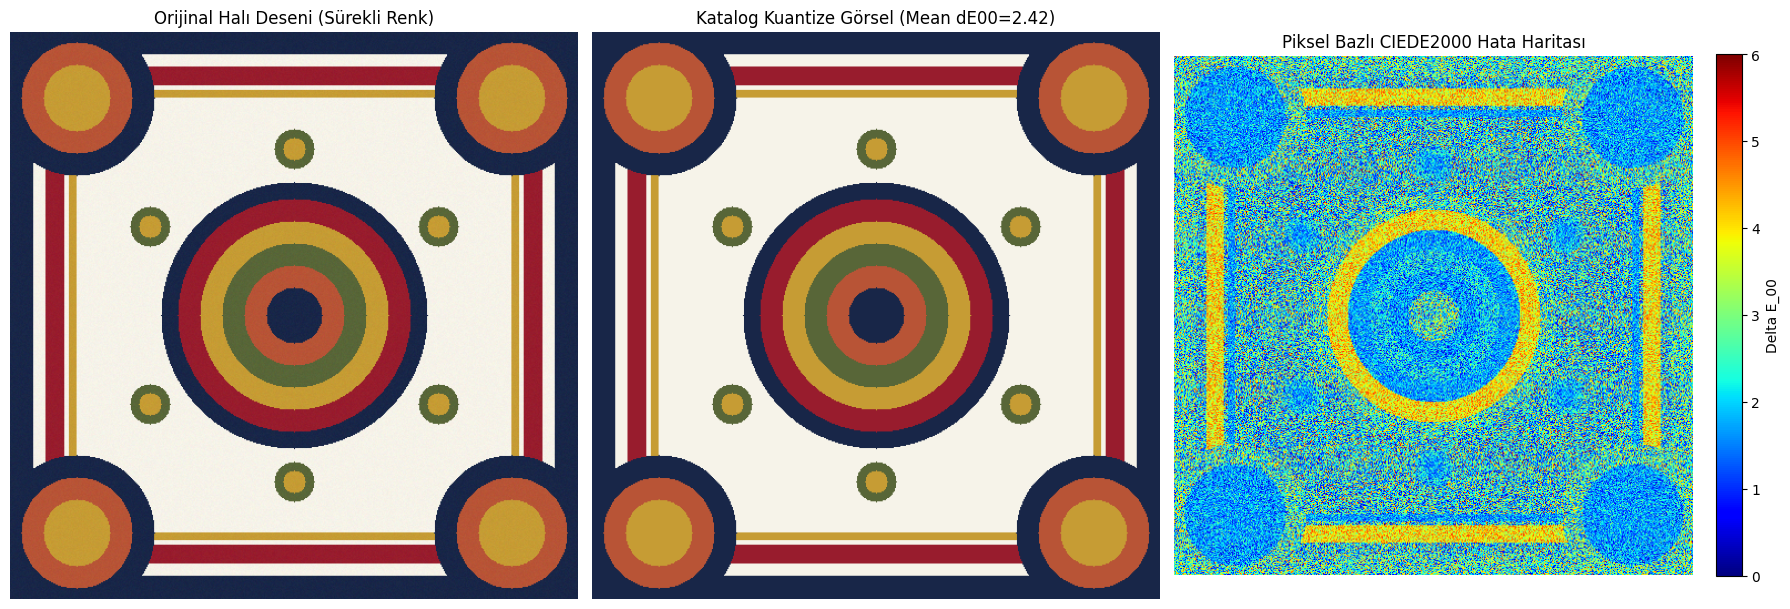

In [7]:
quantizer = CarpetQuantizer(chunk_size=32768)
indexed_map, quantized_bgr, error_map, q_report = quantizer.quantize_to_catalog(
    carpet_oriental, matcher.catalog
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(carpet_oriental, cv2.COLOR_BGR2RGB))
axes[0].set_title("Orijinal Halı Deseni (Sürekli Renk)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(quantized_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Katalog Kuantize Görsel (Mean dE00={q_report.mean_delta_e_00:.2f})")
axes[1].axis("off")

im_err = axes[2].imshow(error_map, cmap="jet", vmin=0, vmax=6)
axes[2].set_title("Piksel Bazlı CIEDE2000 Hata Haritası")
axes[2].axis("off")
fig.colorbar(im_err, ax=axes[2], fraction=0.046, pad=0.04, label="Delta E_00")

plt.tight_layout()
plt.show()

## 10. Mühendislik Çıkarımları, CLI Entegrasyonu ve Day 10'a Bağlantı

### Endüstriyel Kazanımlar:
1. **Tezgâh Kurulum Süresinin Kısaltılması:** Jakarlı tezgâhta renk eşleme ve bobin cağlık ataması manuel numune boyama ile saatler alırken, K-Means + CIEDE2000 hattı ile **1.6 saniyede** otomatikleştirilmiştir.
2. **Algısal Güvenilirlik:** Sharma standart çiftleriyle doğrulanan CIEDE2000 motoru, tekstilde Öklid mesafesinin yol açtığı yanlış iplik seçimlerini sıfırlamıştır.
3. **Maliyet Tahmini:** Desen $m^2$ başına iplik sarfiyat maliyeti tasarım aşamasındayken hesaplanabilmektedir.

### 🚀 Sıradaki Adım: Day 10
**Day 10: Perspektif Düzeltme ve Homografi Matrisi:**
`day10: implement perspective rectification — 4 nokta tespiti, homografi matrisi ve perspektif düzeltme`